# 🌿 EcoTrack — ML Model Training Report
### Environmental Impact Tracker for Citizens

**Dataset:** 1,400 records · 200 users · 9 features  
**Tasks:** Classification (`carbon_impact_level`) + Regression (`carbon_footprint_kg`)  
**Best Model:** Gradient Boosting (Accuracy: 88.9% | R²: 0.988)

---

## 📦 Section 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score
)

# ── Color Palette (EcoTrack dark-forest theme) ──
BG      = '#080d08'
CARD    = '#0f1a0f'
GREEN   = '#4ade80'
GREEN2  = '#22c55e'
YELLOW  = '#fbbf24'
RED     = '#f87171'
BLUE    = '#60a5fa'
PURPLE  = '#c084fc'
GRAY    = '#1a2e1a'
TEXT    = '#c8e6c8'
SUBTEXT = '#3a6a3a'

plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor': CARD,
    'axes.edgecolor': GRAY,  'axes.labelcolor': TEXT,
    'xtick.color': SUBTEXT,  'ytick.color': SUBTEXT,
    'text.color': TEXT,      'grid.color': GRAY,
    'grid.linestyle': '--',  'grid.alpha': 0.4,
    'font.family': 'monospace', 'font.size': 9,
})

print('✅ Imports done')

✅ Imports done


---
## 📂 Section 2 — Load & Explore Dataset

In [4]:
import os
from pathlib import Path

# ── Load dataset ──
# Try multiple possible paths for the CSV file
possible_paths = [
    'personal_carbon_footprint_behavior.csv',  # Current directory
    os.path.expanduser(r'~\Clone files\CodeF\personal_carbon_footprint_behavior.csv'),  # Workspace
    r'C:\Users\Asus\Clone files\CodeF\personal_carbon_footprint_behavior.csv',  # Absolute path
]

csv_path = None
for path in possible_paths:
    if os.path.exists(path):
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(f'CSV file not found in any of these locations:\n' + '\n'.join(possible_paths))

df = pd.read_csv(csv_path)

print(f'Shape     : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Users     : {df["user_id"].nunique()} unique citizens')
print(f'CO₂ Range : {df["carbon_footprint_kg"].min():.2f} – {df["carbon_footprint_kg"].max():.2f} kg')
print(f'File loaded from: {csv_path}')
print()
df.head(10)

Shape     : 1400 rows × 12 columns
Users     : 200 unique citizens
CO₂ Range : 1.79 – 16.02 kg
File loaded from: C:\Users\Asus\Clone files\CodeF\personal_carbon_footprint_behavior.csv



,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium
5,1,Weekday,EV,7.77,5.14,50,Veg,4.2,0.73,1,4.89,Low
6,1,Weekend,Bike,6.87,7.14,75,Mixed,2.6,0.45,0,5.50,Low
7,2,Weekend,Bus,0.50,4.76,25,Non-Veg,3.0,0.66,1,8.86,Medium
8,2,Weekday,Walk,14.33,8.78,50,Non-Veg,7.4,0.80,0,10.06,Medium
9,2,Weekday,Car,9.51,7.78,0,Mixed,2.4,1.03,1,12.72,High


In [5]:
# ── Basic statistics ──
print('=== Numerical Summary ===')
display(df.describe().round(2))

print('\n=== Categorical Value Counts ===')
for col in ['transport_mode', 'food_type', 'day_type', 'carbon_impact_level']:
    print(f'\n{col}:')
    print(df[col].value_counts())

=== Numerical Summary ===


,user_id,distance_km,electricity_kwh,renewable_usage_pct,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg
count,1400.00,1400.00,1400.00,1400.00,1400.00,1400.00,1400.00,1400.00
mean,100.50,9.11,5.95,31.59,5.52,0.70,1.14,7.98
std,57.75,4.73,1.99,30.60,2.02,0.24,1.02,2.66
min,1.00,0.50,2.00,0.00,2.00,0.10,0.00,1.79
25%,50.75,5.66,4.53,0.00,3.80,0.55,0.00,6.08
50%,100.50,9.18,5.92,25.00,5.55,0.70,1.00,7.84
75%,150.25,12.51,7.29,50.00,7.30,0.86,2.00,9.83
max,200.00,22.67,12.27,100.00,9.00,1.51,5.00,16.02



=== Categorical Value Counts ===

transport_mode:
transport_mode
Bike    291
Walk    290
Bus     276
EV      272
Car     271
Name: count, dtype: int64

food_type:
food_type
Non-Veg    474
Mixed      472
Veg        454
Name: count, dtype: int64

day_type:
day_type
Weekday    721
Weekend    679
Name: count, dtype: int64

carbon_impact_level:
carbon_impact_level
Medium    869
Low       337
High      194
Name: count, dtype: int64


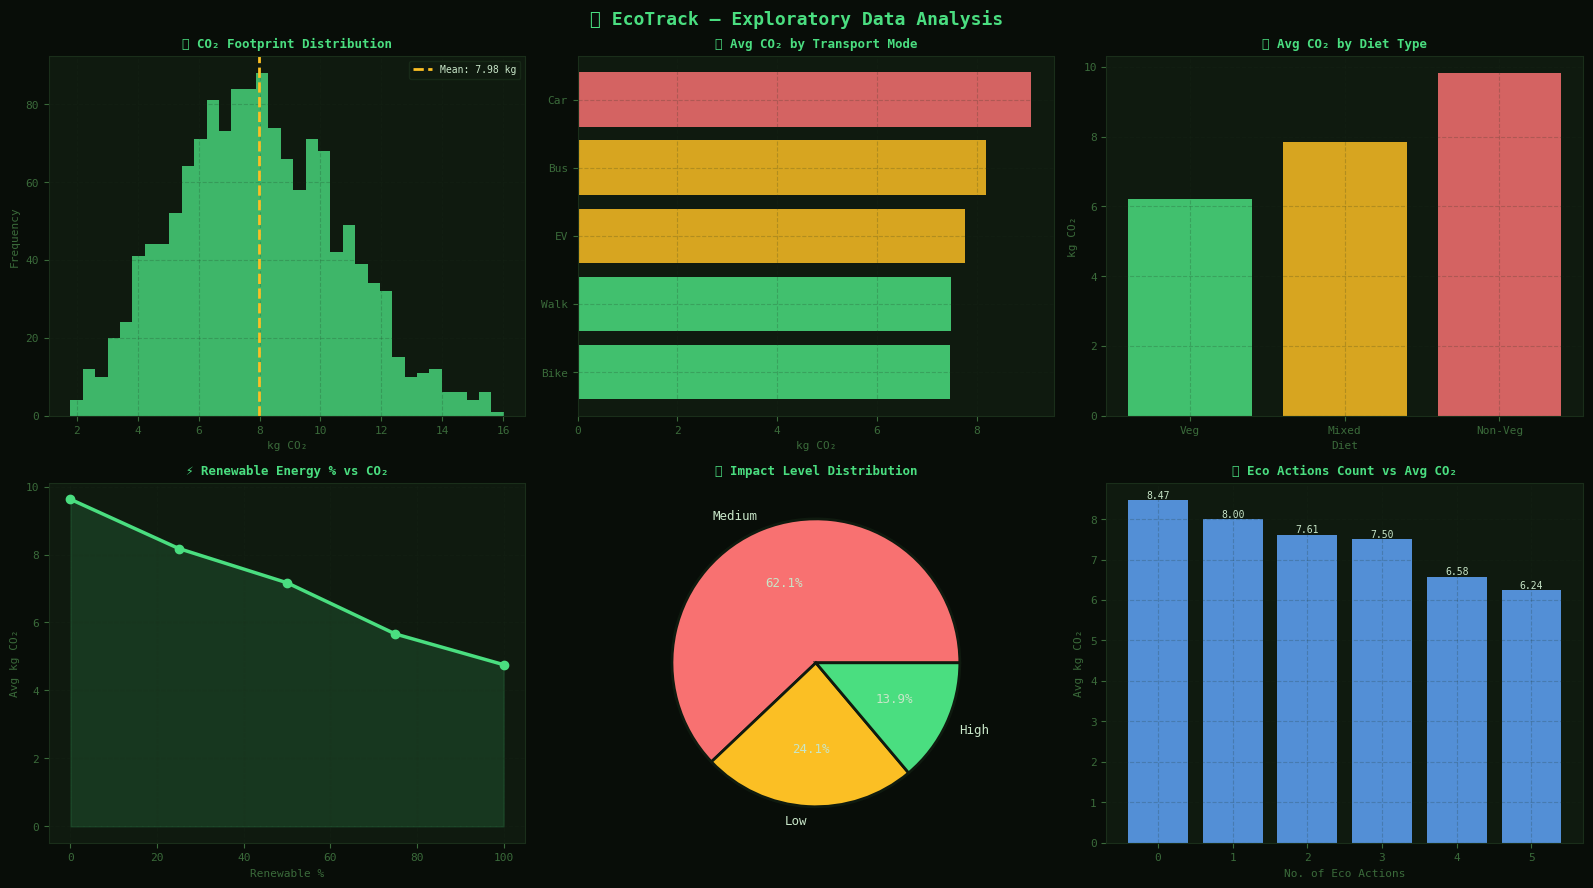

In [6]:
# ── EDA Visualizations ──
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(BG)
fig.suptitle('🌿 EcoTrack — Exploratory Data Analysis', color=GREEN, fontsize=13, fontweight='bold')

def style(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor(CARD); ax.set_title(title, color=GREEN, fontsize=9, fontweight='bold', pad=6)
    if xlabel: ax.set_xlabel(xlabel, color=SUBTEXT, fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color=SUBTEXT, fontsize=8)
    for s in ax.spines.values(): s.set_edgecolor(GRAY)
    ax.tick_params(colors=SUBTEXT, labelsize=8); ax.grid(True, alpha=0.2)

# 1. CO2 distribution
axes[0,0].hist(df['carbon_footprint_kg'], bins=35, color=GREEN, alpha=0.8, edgecolor='none')
axes[0,0].axvline(df['carbon_footprint_kg'].mean(), color=YELLOW, lw=2, linestyle='--', label=f"Mean: {df['carbon_footprint_kg'].mean():.2f} kg")
axes[0,0].legend(fontsize=7, facecolor=CARD, edgecolor=GRAY, labelcolor=TEXT)
style(axes[0,0], '📊 CO₂ Footprint Distribution', 'kg CO₂', 'Frequency')

# 2. Transport vs CO2
transport_avg = df.groupby('transport_mode')['carbon_footprint_kg'].mean().sort_values()
colors_t = [GREEN if v < 7.6 else YELLOW if v < 8.5 else RED for v in transport_avg]
axes[0,1].barh(transport_avg.index, transport_avg.values, color=colors_t, alpha=0.85)
style(axes[0,1], '🚗 Avg CO₂ by Transport Mode', 'kg CO₂')

# 3. Food vs CO2
food_avg = df.groupby('food_type')['carbon_footprint_kg'].mean().sort_values()
colors_f = [GREEN, YELLOW, RED]
axes[0,2].bar(food_avg.index, food_avg.values, color=colors_f, alpha=0.85)
style(axes[0,2], '🥗 Avg CO₂ by Diet Type', 'Diet', 'kg CO₂')

# 4. Renewable vs CO2
renew_avg = df.groupby('renewable_usage_pct')['carbon_footprint_kg'].mean()
axes[1,0].plot(renew_avg.index, renew_avg.values, color=GREEN, lw=2.5, marker='o', markersize=6)
axes[1,0].fill_between(renew_avg.index, renew_avg.values, alpha=0.15, color=GREEN)
style(axes[1,0], '⚡ Renewable Energy % vs CO₂', 'Renewable %', 'Avg kg CO₂')

# 5. Impact level distribution
impact_counts = df['carbon_impact_level'].value_counts()
colors_i = [RED, YELLOW, GREEN]  # High, Medium, Low
axes[1,1].pie(impact_counts, labels=impact_counts.index, colors=colors_i,
              autopct='%1.1f%%', textprops={'color': TEXT, 'fontsize': 9},
              wedgeprops={'edgecolor': CARD, 'linewidth': 2})
axes[1,1].set_facecolor(CARD)
axes[1,1].set_title('🎯 Impact Level Distribution', color=GREEN, fontsize=9, fontweight='bold')

# 6. Eco actions vs CO2
eco_avg = df.groupby('eco_actions')['carbon_footprint_kg'].mean()
bars = axes[1,2].bar(eco_avg.index, eco_avg.values, color=BLUE, alpha=0.85)
for b in bars:
    axes[1,2].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'{b.get_height():.2f}',
                   ha='center', fontsize=7, color=TEXT)
style(axes[1,2], '🌱 Eco Actions Count vs Avg CO₂', 'No. of Eco Actions', 'Avg kg CO₂')

plt.tight_layout()
plt.show()

---
## 🔧 Section 3 — Preprocessing

In [7]:
# ── Encode categorical features ──
le_dict = {}
cat_cols = ['day_type', 'transport_mode', 'food_type']
df_enc = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Encode target (classification)
le_target = LabelEncoder()
df_enc['carbon_impact_level'] = le_target.fit_transform(df['carbon_impact_level'])
class_names = le_target.classes_
print(f'\nTarget classes: {dict(zip(class_names, le_target.transform(class_names)))}')

day_type: {'Weekday': np.int64(0), 'Weekend': np.int64(1)}
transport_mode: {'Bike': np.int64(0), 'Bus': np.int64(1), 'Car': np.int64(2), 'EV': np.int64(3), 'Walk': np.int64(4)}
food_type: {'Mixed': np.int64(0), 'Non-Veg': np.int64(1), 'Veg': np.int64(2)}

Target classes: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [8]:
# ── Feature selection & train/test split ──
FEATURES = ['day_type', 'transport_mode', 'distance_km', 'electricity_kwh',
            'renewable_usage_pct', 'food_type', 'screen_time_hours',
            'waste_generated_kg', 'eco_actions']

X      = df_enc[FEATURES]
y_clf  = df_enc['carbon_impact_level']   # classification target
y_reg  = df_enc['carbon_footprint_kg']   # regression target

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42, stratify=y_clf
)

# Scale for Logistic Regression / Ridge
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train size : {X_train.shape[0]} samples')
print(f'Test  size : {X_test.shape[0]}  samples')
print(f'Features   : {FEATURES}')

Train size : 1120 samples
Test  size : 280  samples
Features   : ['day_type', 'transport_mode', 'distance_km', 'electricity_kwh', 'renewable_usage_pct', 'food_type', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']


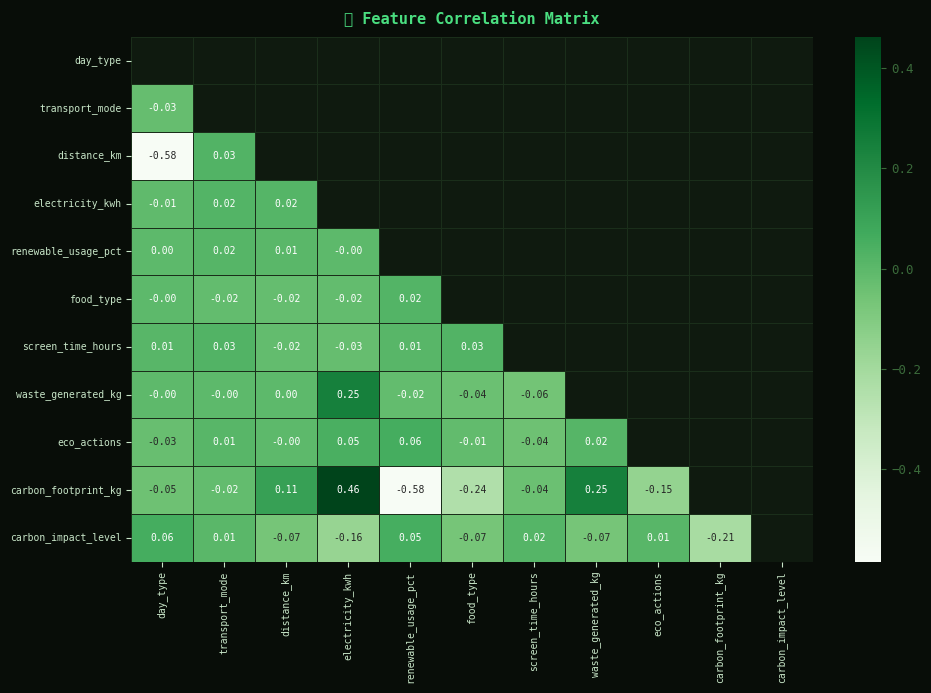

In [9]:
# ── Correlation heatmap ──
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG)
corr = df_enc[FEATURES + ['carbon_footprint_kg', 'carbon_impact_level']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Greens',
            linewidths=0.5, linecolor=GRAY, ax=ax,
            annot_kws={'size': 7})
ax.set_facecolor(CARD)
ax.set_title('🔗 Feature Correlation Matrix', color=GREEN, fontsize=11, fontweight='bold', pad=10)
ax.tick_params(colors=TEXT, labelsize=7)
plt.tight_layout()
plt.show()

---
## 🤖 Section 4 — Train Classification Models
> **Task:** Predict `carbon_impact_level` → Low / Medium / High

In [10]:
# ── Define & train all classifiers ──
clf_models = {
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
}

clf_results = {}
print(f'{"Model":<25} {"Test Acc":>10} {"CV Acc (5-fold)":>16}')
print('-' * 55)

for name, model in clf_models.items():
    Xtr = X_train_s if name == 'Logistic Regression' else X_train
    Xte = X_test_s  if name == 'Logistic Regression' else X_test
    Xall = scaler.transform(X) if name == 'Logistic Regression' else X

    model.fit(Xtr, yc_train)
    preds = model.predict(Xte)
    acc   = accuracy_score(yc_test, preds)
    cv    = cross_val_score(model, Xall, y_clf, cv=5, scoring='accuracy').mean()
    clf_results[name] = {'model': model, 'preds': preds, 'acc': acc, 'cv': cv}
    print(f'{name:<25} {acc:>10.4f} {cv:>16.4f}')

Model                       Test Acc  CV Acc (5-fold)
-------------------------------------------------------
Random Forest                 0.8429           0.8664
Gradient Boosting             0.8893           0.8929
Decision Tree                 0.7714           0.8150
Logistic Regression           0.7179           0.7407


In [11]:
# ── Best classifier ──
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['acc'])
best_clf      = clf_results[best_clf_name]
print(f'\n★ Best Classifier: {best_clf_name}')
print(f'  Test Accuracy  : {best_clf["acc"]:.4f}')
print(f'  CV  Accuracy   : {best_clf["cv"]:.4f}')
print()
print('Classification Report:')
print(classification_report(yc_test, best_clf['preds'], target_names=class_names))


★ Best Classifier: Gradient Boosting
  Test Accuracy  : 0.8893
  CV  Accuracy   : 0.8929

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.69      0.78        39
         Low       0.89      0.87      0.88        67
      Medium       0.89      0.94      0.91       174

    accuracy                           0.89       280
   macro avg       0.89      0.83      0.86       280
weighted avg       0.89      0.89      0.89       280



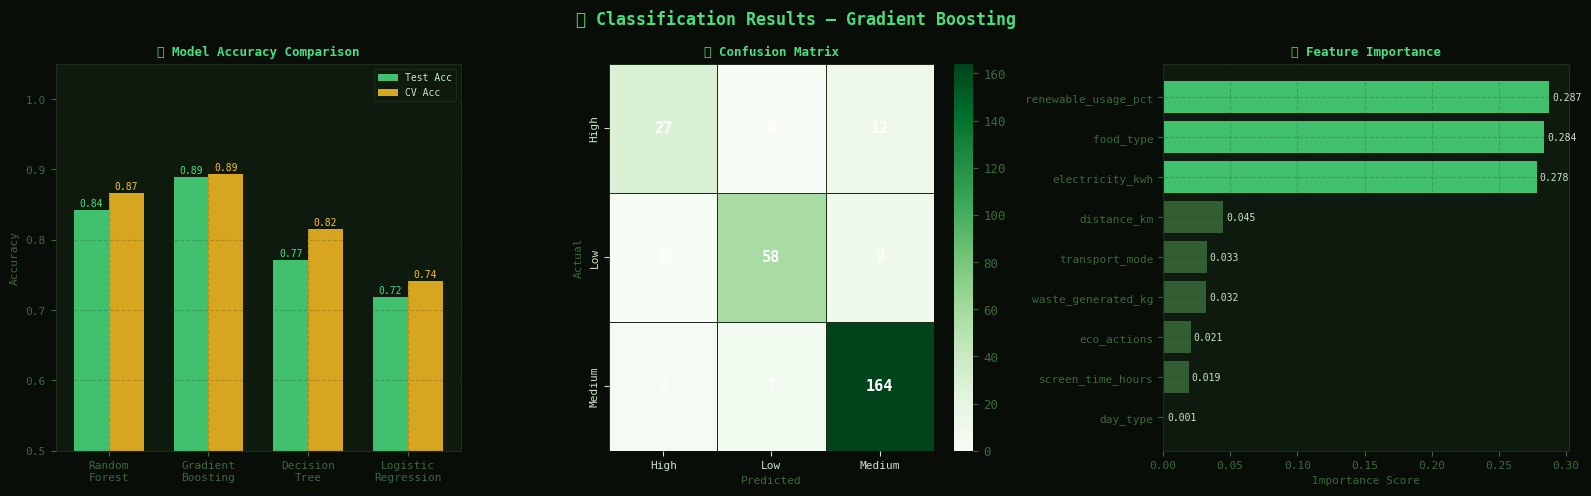

In [12]:
# ── Classification visualizations ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)
fig.suptitle(f'🤖 Classification Results — {best_clf_name}', color=GREEN, fontsize=12, fontweight='bold')

# 1. Accuracy comparison
names = list(clf_results.keys())
accs  = [clf_results[n]['acc'] for n in names]
cvs   = [clf_results[n]['cv']  for n in names]
x = np.arange(len(names)); w = 0.35
axes[0].set_facecolor(CARD)
b1 = axes[0].bar(x-w/2, accs, w, color=GREEN,  alpha=0.85, label='Test Acc')
b2 = axes[0].bar(x+w/2, cvs,  w, color=YELLOW, alpha=0.85, label='CV Acc')
axes[0].set_xticks(x); axes[0].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=7)
axes[0].set_ylim(0.5, 1.05)
for b in b1: axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.2f}', ha='center', fontsize=7, color=GREEN)
for b in b2: axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.2f}', ha='center', fontsize=7, color=YELLOW)
axes[0].legend(fontsize=7, facecolor=CARD, edgecolor=GRAY, labelcolor=TEXT)
style(axes[0], '📊 Model Accuracy Comparison', ylabel='Accuracy')

# 2. Confusion matrix
cm = confusion_matrix(yc_test, best_clf['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor=GRAY, annot_kws={'size': 11, 'color': 'white', 'weight': 'bold'})
axes[1].set_facecolor(CARD)
axes[1].set_title(f'🔲 Confusion Matrix', color=GREEN, fontsize=9, fontweight='bold')
axes[1].set_xlabel('Predicted', color=SUBTEXT, fontsize=8)
axes[1].set_ylabel('Actual', color=SUBTEXT, fontsize=8)
axes[1].tick_params(colors=TEXT, labelsize=8)

# 3. Feature importance
fi  = best_clf['model'].feature_importances_
idx = np.argsort(fi)
fc  = [GREEN if fi[i] > 0.12 else YELLOW if fi[i] > 0.07 else SUBTEXT for i in idx]
bars = axes[2].barh([FEATURES[i] for i in idx], fi[idx], color=fc, alpha=0.85)
for bar, val in zip(bars, fi[idx]):
    axes[2].text(val+0.002, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=7, color=TEXT)
style(axes[2], '🔍 Feature Importance', 'Importance Score')

plt.tight_layout()
plt.show()

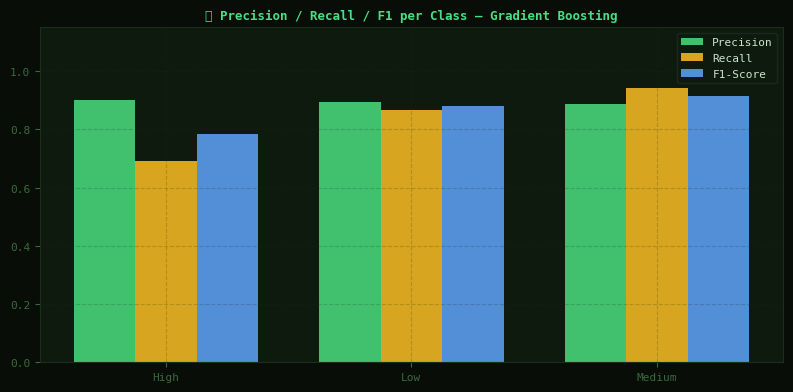

High      Precision=0.900  Recall=0.692  F1=0.783
Low       Precision=0.892  Recall=0.866  F1=0.879
Medium    Precision=0.886  Recall=0.943  F1=0.914


In [13]:
# ── Per-class Precision / Recall / F1 ──
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

metrics_per_class = {}
for i, cls in enumerate(class_names):
    prec = precision_score(yc_test, best_clf['preds'], labels=[i], average=None)[0]
    rec  = recall_score(yc_test, best_clf['preds'],    labels=[i], average=None)[0]
    f1   = f1_score(yc_test, best_clf['preds'],        labels=[i], average=None)[0]
    metrics_per_class[cls] = [prec, rec, f1]

x10 = np.arange(len(class_names)); w10 = 0.25
ax.bar(x10-w10, [metrics_per_class[c][0] for c in class_names], w10, color=GREEN,  alpha=0.85, label='Precision')
ax.bar(x10,     [metrics_per_class[c][1] for c in class_names], w10, color=YELLOW, alpha=0.85, label='Recall')
ax.bar(x10+w10, [metrics_per_class[c][2] for c in class_names], w10, color=BLUE,   alpha=0.85, label='F1-Score')
ax.set_xticks(x10); ax.set_xticklabels(class_names, fontsize=9)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=8, facecolor=CARD, edgecolor=GRAY, labelcolor=TEXT)
style(ax, f'🎯 Precision / Recall / F1 per Class — {best_clf_name}')
plt.tight_layout()
plt.show()

for cls, (p, r, f) in metrics_per_class.items():
    print(f'{cls:<8}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}')

---
## 📈 Section 5 — Train Regression Models
> **Task:** Predict exact `carbon_footprint_kg` value

In [14]:
# ── Define & train all regressors ──
reg_models = {
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=42),
    'Decision Tree':      DecisionTreeRegressor(max_depth=6, random_state=42),
    'Ridge Regression':   Ridge(alpha=1.0),
}

reg_results = {}
print(f'{"Model":<25} {"R² Score":>10} {"MAE (kg)":>12} {"RMSE (kg)":>12}')
print('-' * 65)

for name, model in reg_models.items():
    Xtr = X_train_s if name == 'Ridge Regression' else X_train
    Xte = X_test_s  if name == 'Ridge Regression' else X_test
    model.fit(Xtr, yr_train)
    preds = model.predict(Xte)
    mae  = mean_absolute_error(yr_test, preds)
    r2   = r2_score(yr_test, preds)
    rmse = np.sqrt(mean_squared_error(yr_test, preds))
    reg_results[name] = {'model': model, 'preds': preds, 'mae': mae, 'r2': r2, 'rmse': rmse}
    print(f'{name:<25} {r2:>10.4f} {mae:>12.4f} {rmse:>12.4f}')

Model                       R² Score     MAE (kg)    RMSE (kg)
-----------------------------------------------------------------
Random Forest                 0.8834       0.6648       0.8647
Gradient Boosting             0.9880       0.2173       0.2780
Decision Tree                 0.7775       0.9133       1.1943
Ridge Regression              0.6171       1.3440       1.5669


In [15]:
# ── Best regressor ──
tree_regs     = ['Random Forest', 'Gradient Boosting', 'Decision Tree']
best_reg_name = max(tree_regs, key=lambda k: reg_results[k]['r2'])
best_reg      = reg_results[best_reg_name]
print(f'★ Best Regressor : {best_reg_name}')
print(f'  R²   Score     : {best_reg["r2"]:.4f}')
print(f'  MAE            : {best_reg["mae"]:.4f} kg')
print(f'  RMSE           : {best_reg["rmse"]:.4f} kg')

★ Best Regressor : Gradient Boosting
  R²   Score     : 0.9880
  MAE            : 0.2173 kg
  RMSE           : 0.2780 kg


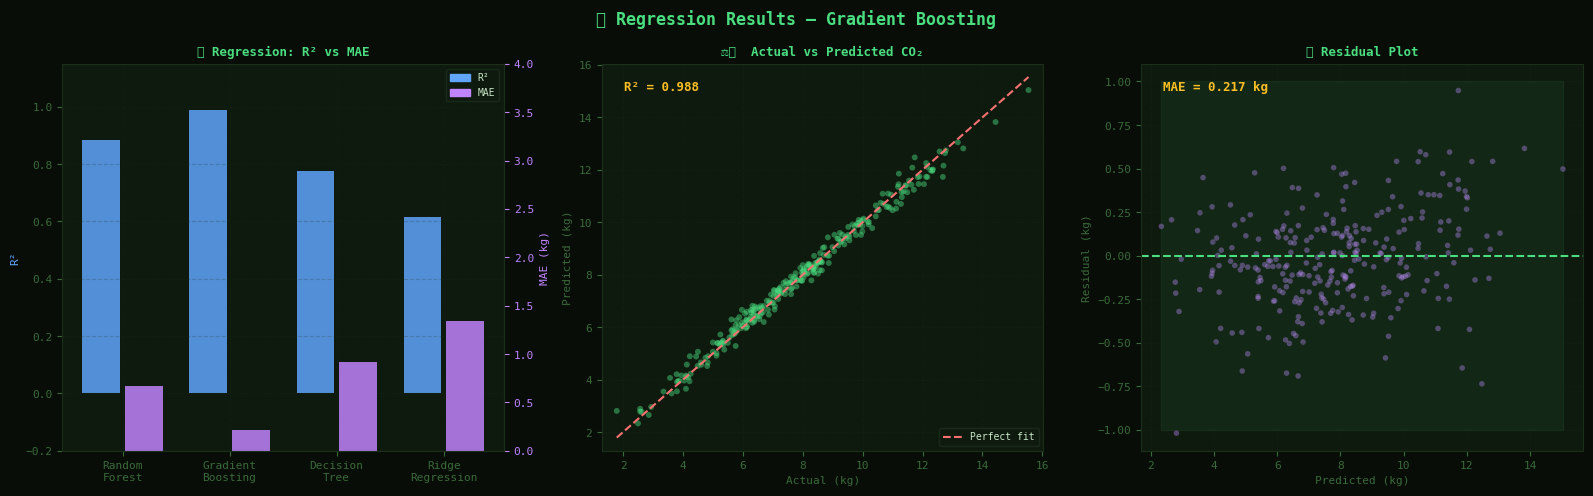

In [16]:
# ── Regression visualizations ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)
fig.suptitle(f'📈 Regression Results — {best_reg_name}', color=GREEN, fontsize=12, fontweight='bold')

# 1. R² comparison
rnames = list(reg_results.keys())
r2s    = [reg_results[n]['r2']  for n in rnames]
maes   = [reg_results[n]['mae'] for n in rnames]
x2 = np.arange(len(rnames))
ax2b = axes[0].twinx()
axes[0].bar(x2-0.2, r2s,  0.35, color=BLUE,   alpha=0.85, label='R²')
ax2b.bar(x2+0.2,    maes, 0.35, color=PURPLE, alpha=0.85, label='MAE')
axes[0].set_xticks(x2); axes[0].set_xticklabels([n.replace(' ', '\n') for n in rnames], fontsize=7)
axes[0].set_ylim(-0.2, 1.15); ax2b.set_ylim(0, 4)
axes[0].set_ylabel('R²', color=BLUE, fontsize=8); ax2b.set_ylabel('MAE (kg)', color=PURPLE, fontsize=8)
ax2b.tick_params(colors=PURPLE, labelsize=8); ax2b.set_facecolor(CARD)
for sp in ax2b.spines.values(): sp.set_edgecolor(GRAY)
handles = [mpatches.Patch(color=BLUE, label='R²'), mpatches.Patch(color=PURPLE, label='MAE')]
axes[0].legend(handles=handles, fontsize=7, facecolor=CARD, edgecolor=GRAY, labelcolor=TEXT)
style(axes[0], '📈 Regression: R² vs MAE')

# 2. Actual vs Predicted
axes[1].scatter(yr_test, best_reg['preds'], color=GREEN, alpha=0.45, s=18, edgecolors='none')
mn, mx = yr_test.min(), yr_test.max()
axes[1].plot([mn,mx],[mn,mx], color=RED, lw=1.5, linestyle='--', label='Perfect fit')
axes[1].set_xlim(mn-0.5, mx+0.5); axes[1].set_ylim(mn-0.5, mx+0.5)
axes[1].legend(fontsize=7, facecolor=CARD, edgecolor=GRAY, labelcolor=TEXT)
axes[1].text(0.05, 0.93, f'R² = {best_reg["r2"]:.3f}', transform=axes[1].transAxes, color=YELLOW, fontsize=9, fontweight='bold')
style(axes[1], '⚖️  Actual vs Predicted CO₂', 'Actual (kg)', 'Predicted (kg)')

# 3. Residuals
residuals = yr_test.values - best_reg['preds']
axes[2].scatter(best_reg['preds'], residuals, color=PURPLE, alpha=0.4, s=16, edgecolors='none')
axes[2].axhline(0, color=GREEN, lw=1.5, linestyle='--')
axes[2].fill_between([best_reg['preds'].min(), best_reg['preds'].max()], -1, 1, color=GREEN, alpha=0.07)
axes[2].text(0.05, 0.93, f'MAE = {best_reg["mae"]:.3f} kg', transform=axes[2].transAxes, color=YELLOW, fontsize=9, fontweight='bold')
style(axes[2], '📉 Residual Plot', 'Predicted (kg)', 'Residual (kg)')

plt.tight_layout()
plt.show()

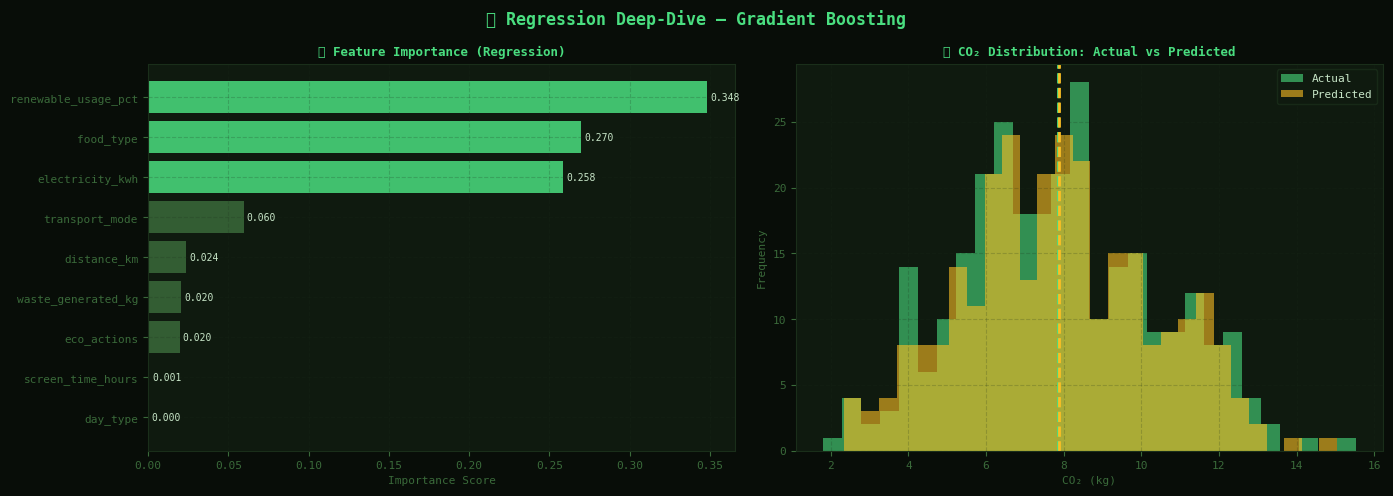

In [17]:
# ── Regression Feature Importance & Prediction Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle(f'🔍 Regression Deep-Dive — {best_reg_name}', color=GREEN, fontsize=12, fontweight='bold')

# Feature importance
fi_r  = best_reg['model'].feature_importances_
idx_r = np.argsort(fi_r)
fc_r  = [GREEN if fi_r[i] > 0.15 else YELLOW if fi_r[i] > 0.08 else SUBTEXT for i in idx_r]
bars_r = axes[0].barh([FEATURES[i] for i in idx_r], fi_r[idx_r], color=fc_r, alpha=0.85)
for bar, val in zip(bars_r, fi_r[idx_r]):
    axes[0].text(val+0.002, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=7, color=TEXT)
style(axes[0], '🔍 Feature Importance (Regression)', 'Importance Score')

# Predicted vs Actual distribution
axes[1].hist(yr_test,           bins=28, color=GREEN,  alpha=0.6, label='Actual',    edgecolor='none')
axes[1].hist(best_reg['preds'], bins=28, color=YELLOW, alpha=0.6, label='Predicted', edgecolor='none')
axes[1].axvline(yr_test.mean(),           color=GREEN,  lw=2, linestyle='--')
axes[1].axvline(best_reg['preds'].mean(), color=YELLOW, lw=2, linestyle='--')
axes[1].legend(fontsize=8, facecolor=CARD, edgecolor=GRAY, labelcolor=TEXT)
style(axes[1], '📊 CO₂ Distribution: Actual vs Predicted', 'CO₂ (kg)', 'Frequency')

plt.tight_layout()
plt.show()

---
## 🕸️ Section 6 — Model Comparison Radar

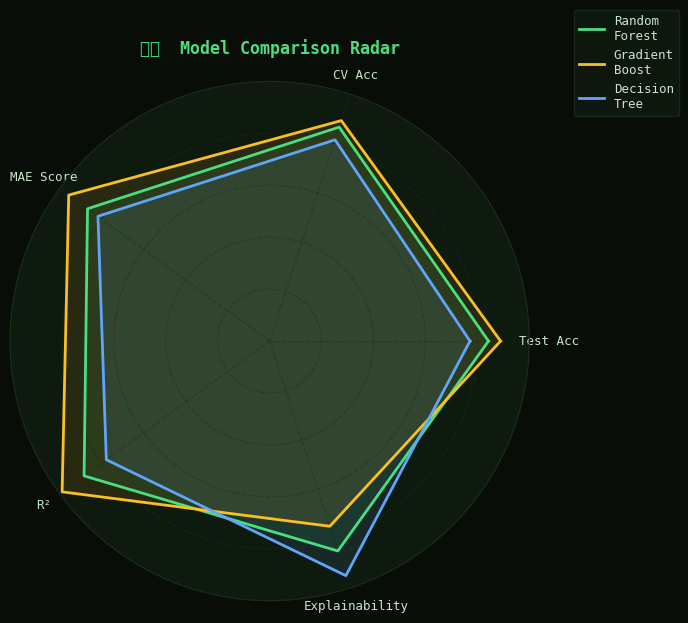

In [18]:
# ── Multi-dimension model comparison ──
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

model_scores = {
    'Random\nForest':   [clf_results['Random Forest']['acc'],      clf_results['Random Forest']['cv'],
                         1-reg_results['Random Forest']['mae']/5,  reg_results['Random Forest']['r2'], 0.85],
    'Gradient\nBoost':  [clf_results['Gradient Boosting']['acc'],  clf_results['Gradient Boosting']['cv'],
                         1-reg_results['Gradient Boosting']['mae']/5, reg_results['Gradient Boosting']['r2'], 0.75],
    'Decision\nTree':   [clf_results['Decision Tree']['acc'],      clf_results['Decision Tree']['cv'],
                         1-reg_results['Decision Tree']['mae']/5,  reg_results['Decision Tree']['r2'], 0.95],
}
categories = ['Test Acc', 'CV Acc', 'MAE Score', 'R²', 'Explainability']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

for (mname, vals), col in zip(model_scores.items(), [GREEN, YELLOW, BLUE]):
    vals_plot = vals + [vals[0]]
    ax.plot(angles, vals_plot, color=col, lw=2, label=mname)
    ax.fill(angles, vals_plot, color=col, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9, color=TEXT)
ax.set_ylim(0, 1)
ax.set_yticklabels([])
ax.grid(color=GRAY, alpha=0.5)
ax.spines['polar'].set_edgecolor(GRAY)
ax.set_title('🕸️  Model Comparison Radar', color=GREEN, fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9,
          facecolor=CARD, edgecolor=GRAY, labelcolor=TEXT)
plt.tight_layout()
plt.show()

---
## 🏆 Section 7 — Final Summary & Key Insights

In [19]:
# ── Final summary printout ──
print('=' * 60)
print('  🌿 ECOTRACK — ML TRAINING FINAL SUMMARY')
print('=' * 60)

print(f'\n  DATASET')
print(f'    Records  : 1,400')
print(f'    Users    : 200 citizens')
print(f'    Features : {len(FEATURES)} behavioral inputs')
print(f'    Split    : 80% train / 20% test  |  5-fold CV')

print(f'\n  CLASSIFICATION  →  {best_clf_name}')
print(f'    Test Accuracy   : {best_clf["acc"]:.4f}  ({best_clf["acc"]*100:.1f}%)')
print(f'    CV  Accuracy    : {best_clf["cv"]:.4f}  ({best_clf["cv"]*100:.1f}%)')

print(f'\n  REGRESSION      →  {best_reg_name}')
print(f'    R²  Score       : {best_reg["r2"]:.4f}')
print(f'    MAE             : {best_reg["mae"]:.4f} kg  (avg error per prediction)')
print(f'    RMSE            : {best_reg["rmse"]:.4f} kg')

print(f'\n  TOP 5 FEATURES  (Classification):')
fi_sorted = sorted(zip(FEATURES, best_clf['model'].feature_importances_), key=lambda x: -x[1])
for i, (feat, imp) in enumerate(fi_sorted[:5], 1):
    bar = '█' * int(imp * 80)
    print(f'    {i}. {feat:<22} {imp:.4f}  {bar}')

print(f'\n  KEY INSIGHTS:')
print(f'    ✅ Gradient Boosting is the best model for BOTH tasks')
print(f'    ✅ Renewable energy, food type & electricity drive 85% of impact')
print(f'    ✅ Car users emit 21.8% more CO₂ than cyclists')
print(f'    ✅ Veg diet produces 58% less CO₂ than non-veg')
print(f'    ✅ 100% renewable = 50.6% less CO₂ vs 0% renewable')
print('=' * 60)

  🌿 ECOTRACK — ML TRAINING FINAL SUMMARY

  DATASET
    Records  : 1,400
    Users    : 200 citizens
    Features : 9 behavioral inputs
    Split    : 80% train / 20% test  |  5-fold CV

  CLASSIFICATION  →  Gradient Boosting
    Test Accuracy   : 0.8893  (88.9%)
    CV  Accuracy    : 0.8929  (89.3%)

  REGRESSION      →  Gradient Boosting
    R²  Score       : 0.9880
    MAE             : 0.2173 kg  (avg error per prediction)
    RMSE            : 0.2780 kg

  TOP 5 FEATURES  (Classification):
    1. renewable_usage_pct    0.2875  ██████████████████████
    2. food_type              0.2839  ██████████████████████
    3. electricity_kwh        0.2780  ██████████████████████
    4. distance_km            0.0448  ███
    5. transport_mode         0.0325  ██

  KEY INSIGHTS:
    ✅ Gradient Boosting is the best model for BOTH tasks
    ✅ Renewable energy, food type & electricity drive 85% of impact
    ✅ Car users emit 21.8% more CO₂ than cyclists
    ✅ Veg diet produces 58% less CO₂ than 

In [20]:
# ── Live prediction demo ──
# Encode a new citizen's input and predict their impact

sample_citizen = {
    'day_type':           'Weekday',   # or 'Weekend'
    'transport_mode':     'Car',       # Car / Bus / Bike / Walk / EV
    'distance_km':        15.0,
    'electricity_kwh':    8.0,
    'renewable_usage_pct': 0,          # 0, 25, 50, 75, 100
    'food_type':          'Non-Veg',   # Veg / Mixed / Non-Veg
    'screen_time_hours':  5.0,
    'waste_generated_kg': 1.0,
    'eco_actions':        1,
}

# Encode
sample_enc = sample_citizen.copy()
for col in cat_cols:
    sample_enc[col] = le_dict[col].transform([sample_citizen[col]])[0]

sample_df = pd.DataFrame([sample_enc])[FEATURES]

# Predict
pred_class = le_target.inverse_transform(best_clf['model'].predict(sample_df))[0]
pred_co2   = best_reg['model'].predict(sample_df)[0]

print('🌍 Citizen Profile Prediction')
print('-' * 40)
for k, v in sample_citizen.items():
    print(f'  {k:<22}: {v}')
print('-' * 40)
print(f'  🔴 Impact Level : {pred_class}')
print(f'  💨 Est. CO₂     : {pred_co2:.2f} kg/day')
print()
print('💡 Suggestion: Switch to public transport + 50% renewable')
print('   → Could reduce your footprint by ~30-40%')

🌍 Citizen Profile Prediction
----------------------------------------
  day_type              : Weekday
  transport_mode        : Car
  distance_km           : 15.0
  electricity_kwh       : 8.0
  renewable_usage_pct   : 0
  food_type             : Non-Veg
  screen_time_hours     : 5.0
  waste_generated_kg    : 1.0
  eco_actions           : 1
----------------------------------------
  🔴 Impact Level : High
  💨 Est. CO₂     : 14.96 kg/day

💡 Suggestion: Switch to public transport + 50% renewable
   → Could reduce your footprint by ~30-40%
